In [ ]:
import os
import glob
import json
import pprint
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset

from pyperf.utils.patch_parser import SimplePatchParser
from pyperf.harness.utils import natural_sort_key
from pyperf.constants import SUBMISSIONS_DIR

pd.set_option("future.no_silent_downcasting", True)
# plt.rcParams.update({"font.size": 14})
pp = pprint.PrettyPrinter(indent=2)

In [ ]:
# experiment config
EXP_NAME = "scale"
RES_EXP_NAME = "scale"
RUN_PREFIX = "run-"
DATASET_NAME = "manishs/pyperf-extended"

In [ ]:
def get_traces(pattern: str):
    traces = list(SUBMISSIONS_DIR.glob(pattern))
    if traces == []:
        print(f"Could not find any traces matching pattern: {pattern}")
    traces = sorted([str(t) for t in traces], key=natural_sort_key)
    return [Path(t) for t in traces]


def load_json(fname):
    with open(fname, "r") as f:
        return json.load(f)

In [ ]:
HOME_DIR = Path(os.path.expanduser("~"))
EVAL_REPORTS_DIR = HOME_DIR / "pyperf/reports"


def get_model_config(model_alias: str):
    """
    Return the model configuration based on the model alias.

    Args:
        model_alias (str): The alias of the model, e.g. "claude" or "o3-mini".

    Returns:
        tuple: (model, beat_k, run_id_range)
    """
    if model_alias == "claude":
        model = "claude-3-5-sonnet-v2-20241022"
        beat_k = 15
    elif model_alias == "o3-mini":
        model = "o3-mini"
        beat_k = 10
    elif model_alias == "o4-mini":
        model = "o4-mini"
        beat_k = 10
    elif model_alias == "gpt-4o":
        model = "gpt-4o"
        beat_k = 15
    else:
        raise ValueError(f"Unknown model alias: {model_alias}")

    run_id_range = [0, beat_k]
    return model, beat_k, run_id_range


def load_evaluation_data(model_alias: str, beat_k: int, model: str):
    eval_report = (
        EVAL_REPORTS_DIR
        / "beat_k_reports"
        / f"{model_alias}.beat@{beat_k}.scale.report.json"
    )
    report = load_json(eval_report)
    traces = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.jsonl"
    )
    submissions = get_traces(
        f"manishs__pyperf-test/CodeActAgent/scale/{model}_maxiter_100_N_v0.35.0-no-hint-run_*/output.pyperf.jsonl"
    )
    return report, traces, submissions

#### Collect Dataset

In [ ]:
dataset = load_dataset(DATASET_NAME, split="test")
print(f"Filtered dataset size: {len(dataset)}")

#### Collect Submissions

In [ ]:
def load_traces_to_df(trace_files, run_id_range):
    traces_data = []

    for trace_file in tqdm(trace_files, desc="Loading trace files"):
        run_id = trace_file.parent.name  # Extract run ID from path

        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        with open(trace_file, "r") as f:
            for line in f:
                try:
                    trace = json.loads(line)
                    if "instance_id" in trace:
                        trace["run_id"] = run_id
                        traces_data.append(trace)
                except json.JSONDecodeError:
                    continue

    traces_df = pd.DataFrame(traces_data)

    # Print info about the dataframe
    print(f"Loaded {len(traces_df)} trace entries")
    print(f"Unique instance IDs: {traces_df["instance_id"].nunique()}")
    print(f"Unique run IDs: {traces_df["run_id"].nunique()}")

    return traces_df

#### Collect Evaluations

In [ ]:
def load_opt_stats_data(report, run_id_range):
    opt_stats = report["opt_stats"]
    opt_stats_data = []

    for instance_id, stats in opt_stats.items():
        run_id = stats["report_file"].split("/")[-1].rstrip(f"{EXP_NAME}.report.json")
        run_id_num = int(run_id.split("_")[-1])
        if run_id_num < run_id_range[0] or run_id_num > run_id_range[1]:
            continue

        possible_reports = list(
            EVAL_REPORTS_DIR.glob(f"*{run_id}.{EXP_NAME}.report.json")
        )
        if not possible_reports:
            continue

        report_path = possible_reports[0]
        with open(report_path, "r") as report_file:
            report_data = json.load(report_file)

        beat_commit = instance_id in report_data.get("instance_sets", {}).get(
            "beat_commit_ids", []
        )
        stats_dict = {
            "instance_id": instance_id,
            "run_id": run_id,
            "beat_commit": beat_commit,
            **stats,
        }
        opt_stats_data.append(stats_dict)

    # Convert to DataFrame
    opt_stats_df = pd.DataFrame(opt_stats_data)
    print(f"Loaded {len(opt_stats_df)} entries from opt_stats")

    return opt_stats_df

#### Merge

In [ ]:
def merge_dataframes(traces_df, opt_stats_df, dataset):
    # Sort the traces dataframe
    traces_df = traces_df.sort_values(["instance_id", "run_id"])
    dataset_df = pd.DataFrame(dataset)

    # drop rows with instance_id not in dataset_df
    traces_df = traces_df[traces_df["instance_id"].isin(dataset_df["instance_id"])]
    opt_stats_df = opt_stats_df[
        opt_stats_df["instance_id"].isin(dataset_df["instance_id"])
    ]

    merged_df = pd.merge(
        traces_df,
        opt_stats_df,
        on=["instance_id", "run_id"],
        how="outer",
        suffixes=("_trace", "_stats"),
    )
    merged_df = pd.merge(
        merged_df,
        dataset_df,
        on="instance_id",
        how="outer",
        suffixes=("_merged", "_dataset"),
    )

    merged_df.fillna({"beat_commit": False}, inplace=True)

    print(f"Merged dataframe has {len(merged_df)} rows")
    print(f"Merged dataframe has {len(merged_df.columns)} columns")
    print(
        f"Instances with both trace and stats: {merged_df.dropna(subset=['instance_id', 'run_id']).shape[0]}"
    )

    return merged_df

#### Data Helpers

In [ ]:
def get_diff_stats(patch, prefix=""):
    parser = SimplePatchParser()
    diff = parser.parse_patch(patch, old_commit_hash="")
    stats = {
        f"{prefix}num_files": diff.num_non_test_files,
        f"{prefix}num_hunks": diff.num_hunks,  # note: includes test files?
        f"{prefix}num_edited_lines": diff.num_non_test_edited_lines,
        f"{prefix}files_changed": [
            file_diff.path
            for file_diff in diff.file_diffs
            if file_diff.is_test_file is False
        ],
    }

    # remove any files starting with .venv or .git
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if not file.startswith((".venv", ".git"))
    ]

    stats[f"{prefix}extensions"] = extensions_from_filenames(
        stats[f"{prefix}files_changed"]
    )

    # update files_changed to only include good extensions
    stats[f"{prefix}files_changed"] = [
        file
        for file in stats[f"{prefix}files_changed"]
        if file.split(".")[-1] in stats[f"{prefix}extensions"]
    ]
    stats[f"{prefix}num_files"] = len(stats[f"{prefix}files_changed"])

    return stats


def extensions_from_filenames(files):
    ignore_list = {
        "rst",
        "txt",
        "json",
        "md",
        "csv",
        "pkl",
        "yaml",
        "yml",
        "mdx",
        "tif",
        "tiff",
        "png",
        "jpg",
        "jpeg",
        "gif",
        "webp",
        "bmp",
        "ico",
        "svg",
        "pdf",
        "gitignore",
        "lock",
        "zip",
        "tar",
        "gz",
        "bz2",
        "xz",
        "toml",
        "npy",
        "tmpl",
        "html",
        "build",
        "venv/lib64",
        "cfg",
        "patch",
        "numpy/_core/src/npysort/x86-simd-sort",
        "numpy/core/src/npysort/x86-simd-sort",
        "Makefile",
        "ipynb",
        "ini",
        "fli",
    }
    extensions = {file.split(".")[-1] for file in files}
    return extensions - ignore_list

In [ ]:
def get_agent_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "agent" and item.get("message")
    ]


def get_user_messages(history_list):
    if not history_list:
        return []

    return [
        {
            "id": item.get("id"),
            "message": item.get("message", ""),
            "timestamp": item.get("timestamp"),
        }
        for item in history_list
        if item.get("source") == "user" and item.get("message")
    ]


def get_tool_calls(history_list):
    if not history_list:
        return []

    tool_calls = []
    for item in history_list:
        if item.get("tool_call_metadata") and item.get("action"):
            try:
                metadata = item["tool_call_metadata"]
                function_name = metadata.get("function_name", "")
                tool_call_id = metadata.get("tool_call_id", "")
                step_id = item.get("id")

                # Extract command arguments if available
                arguments = None
                if (
                    metadata.get("model_response")
                    and metadata["model_response"].get("choices")
                    and metadata["model_response"]["choices"][0].get("message")
                    and metadata["model_response"]["choices"][0]["message"].get(
                        "tool_calls"
                    )
                ):

                    tool_call = metadata["model_response"]["choices"][0]["message"][
                        "tool_calls"
                    ][0]
                    if tool_call.get("function") and tool_call["function"].get(
                        "arguments"
                    ):
                        try:
                            arguments = json.loads(tool_call["function"]["arguments"])
                        except:
                            arguments = tool_call["function"]["arguments"]

                tool_calls.append(
                    {
                        "step_id": step_id,
                        "function_name": function_name,
                        "arguments": arguments,
                        "action": item.get("action"),
                    }
                )
            except Exception as e:
                # Skip tool calls that can't be parsed
                pass

    return tool_calls


def get_observations(history_list):
    if not history_list:
        return []

    observations = []
    for item in history_list:
        if not item.get("action") and item.get("cause"):
            observations.append(
                {
                    "id": item.get("id"),
                    "cause_id": item.get(
                        "cause"
                    ),  # Step ID that caused this observation
                    "message": item.get("message", ""),
                    "content": item.get("content", ""),
                    "error": item.get("error", ""),
                    "timestamp": item.get("timestamp"),
                    "success": item.get(
                        "success", True
                    ),  # Assume success unless explicitly marked as failed
                }
            )

    return observations


def get_action_sequence(history_list):
    if not history_list:
        return []

    return [
        {
            "step_id": item.get("id"),
            "action": item.get("action"),
            "timestamp": item.get("timestamp"),
            "source": item.get("source"),
        }
        for item in history_list
        if item.get("action")
    ]


def get_rebuilds(history_list):
    tool_calls = get_tool_calls(history_list)
    rebuilds = []
    for tool_call in tool_calls:
        if tool_call.get("arguments") and tool_call["arguments"].get("command"):
            command = tool_call["arguments"]["command"]
            if "pip install" in command:
                rebuilds.append(tool_call)
    return rebuilds


############# Counter functions #############
def get_step_counts(history_list):
    if not history_list:
        return 0

    return sum(1 for item in history_list if item.get("action"))


def get_action_counts(history_list):
    if not history_list:
        return {}

    action_counts = {}
    for item in history_list:
        action = item.get("action")
        if action:
            if action in action_counts:
                action_counts[action] += 1
            else:
                action_counts[action] = 1

    return action_counts


def get_conversation_summary(history):
    step_count = get_step_counts(history)
    action_counts = get_action_counts(history)
    rebuild_count = len(get_rebuilds(history))
    is_finished = action_counts.get("finish", 0) == 1

    return {
        "step_count": step_count,
        "action_counts": action_counts,
        "rebuild_count": rebuild_count,
        "is_finished": is_finished,
    }

In [ ]:
def extract_per_test_times(per_test_means):
    if not per_test_means or (pd.isna(per_test_means)):
        return {
            "base_times": [],
            "patch_times": [],
            "commit_times": [],
            # "main_times": [],
        }
    return {
        f"{key}_times": value
        for key, value in per_test_means.items()
        if key in ["base", "patch", "commit"]
    }


def extract_per_test_speedups(per_test_means):
    if not per_test_means or pd.isna(per_test_means):
        return {
            f"{a}_{b}_speedups": []
            for a, b in [
                ("patch", "base"),
                ("commit", "base"),
                # ("main", "base"),
                ("patch", "commit"),
            ]
        }

    # Simple list comprehensions for each type of speedup
    result = {}

    # Calculate speedups with safe division
    result["patch_base_speedups"] = [
        b / p if p > 0 else float("inf")
        for b, p in zip(per_test_means["base"], per_test_means["patch"])
        if b > 0
    ]

    result["commit_base_speedups"] = [
        b / c if c > 0 else float("inf")
        for b, c in zip(per_test_means["base"], per_test_means["commit"])
        if b > 0
    ]

    # result["main_base_speedups"] = [
    #     b / m if m > 0 else float("inf")
    #     for b, m in zip(per_test_means["base"], per_test_means["main"])
    #     if b > 0
    # ]

    result["patch_commit_speedups"] = [
        c / p if p > 0 else float("inf")
        for c, p in zip(per_test_means["commit"], per_test_means["patch"])
        if c > 0
    ]

    return result

In [ ]:
def prepare_analysis_row(df_row):
    # Extract relevant columns
    instance_id = df_row["instance_id"]
    run_id = df_row["run_id"]
    repo = df_row["repo"]
    api = df_row["api"]

    gt_commit = df_row["base_commit"].rstrip("^")
    gt_commit_link = f"https://github.com/{repo}/commit/{gt_commit}"
    gt_patch = df_row["gt_diff"]
    gt_files_changed = df_row["gt_files_changed"]
    gt_commit_stats = get_diff_stats(gt_patch, prefix="gt_")

    model_patch = df_row["test_result"].get("git_patch", "")
    model_patch_stats = get_diff_stats(model_patch, prefix="patch_")
    history = df_row["history"]

    # keep these optimization stats:
    stats_to_keep = [
        "opt_perc_patch_base",
        "opt_perc_patch_commit",
        # "opt_perc_patch_main",
        "speedup_patch_base",
        "speedup_patch_commit",
        # "speedup_patch_main",
        "gm_speedup_patch_base",
        "gm_speedup_patch_commit",
        # "gm_speedup_patch_main",
        "gsd_speedup_patch_base",
        "gsd_speedup_patch_commit",
        # "gsd_speedup_patch_main",
        "base_mean",
        "base_std",
        "patch_mean",
        "patch_std",
        "commit_mean",
        "commit_std",
        # "main_mean",
        # "main_std",
        "report_file",
        "history",
    ]

    opt_stats = {k: df_row[k] for k in stats_to_keep if k in df_row}

    # Create a dictionary for the analysis row
    analysis_row = {
        "instance_id": instance_id,
        "run_id": run_id,
        "model_patch": model_patch,
        "gt_commit": gt_commit,
        "repo": repo,
        "repo_name": repo.split("/")[-1],
        "api": api,
        "gt_files_changed": gt_files_changed,
        "gt_patch": gt_patch,
        "gt_extensions": extensions_from_filenames(gt_files_changed),
        **gt_commit_stats,
        **model_patch_stats,
        **get_conversation_summary(history),
        **opt_stats,
        **extract_per_test_times(df_row["per_test_means"]),
        **extract_per_test_speedups(df_row["per_test_means"]),
    }

    # add the beat_commit renamed to beat
    analysis_row["beat"] = df_row["beat_commit"]

    return analysis_row


def make_analysis_df(merged_df):
    analysis_df = merged_df.apply(prepare_analysis_row, axis=1, result_type="expand")
    print(f"Analysis dataframe has {len(analysis_df)} rows")
    print(f"Analysis dataframe has {len(analysis_df.columns)} columns")
    return analysis_df

#### Analysis

In [ ]:
# model_alias = "claude"
# model, beat_k, run_id_range = get_model_config(model_alias)
# report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
# traces_df = load_traces_to_df(traces, run_id_range)
# opt_stats_df = load_opt_stats_data(report, run_id_range)
# merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
# analysis_df = make_analysis_df(merged_df)

model_alias = "o4-mini"
model, beat_k, run_id_range = get_model_config(model_alias)
report, traces, submissions = load_evaluation_data(model_alias, beat_k, model)
traces_df = load_traces_to_df(traces, run_id_range)
opt_stats_df = load_opt_stats_data(report, run_id_range)
merged_df = merge_dataframes(traces_df, opt_stats_df, dataset)
analysis_df = make_analysis_df(merged_df)

##### Qualitative Analysis of trajectories by LLM

In [ ]:
from r2e.llms.completions import LLMCompletions
import os
import re
import tiktoken
from r2e.llms.llm_args import LLMArgs

tokenizer = tiktoken.encoding_for_model("gpt-4")

In [ ]:
def count_tokens(context: str):
    return len(tokenizer.encode(context, disallowed_special=()))

In [ ]:
def history_to_string(history_list, max_tokens=500):
    """
    Converts history list into a string format with each item structured as:

    STEP ID: X
    SOURCE: Y
    CONTENT: Z

    Parameters:
    - history_list: List of history dictionaries
    - max_tokens: Maximum number of tokens for long text fields

    Returns:
    - String representation of the history
    """
    # Handle None or empty history
    if history_list is None or len(history_list) == 0:
        return "NO HISTORY AVAILABLE"

    result = []

    for item in history_list:
        # Start building the string representation for this item
        step_str = [f"STEP ID: {item.get('id', 'N/A')}"]
        step_str.append(f"SOURCE: {item.get('source', 'N/A')}")

        # Handle content based on the source
        if item.get("source") == "user":
            # For user messages, use the 'message' field or 'args.content' field
            content = item.get("message", "")
            if (
                not content
                and "args" in item
                and isinstance(item["args"], dict)
                and "content" in item["args"]
            ):
                content = item["args"]["content"]

            # If content is too long, truncate it
            if content and count_tokens(content) > max_tokens:
                # Approximate truncation
                approx_chars = int(
                    max_tokens * 3.5
                )  # Rough estimate: 1 token ≈ 3-4 chars
                content = content[:approx_chars] + "...(truncated)..."

            step_str.append(f"CONTENT: {content}")

        elif item.get("source") == "agent":
            # Check if this is an observation
            if "observation" in item:
                content = f"OBSERVATION: {item.get('observation', '')}"

                # If there's additional content in the 'content' field, add it
                if "content" in item and item["content"]:
                    observation_content = item["content"]
                    if count_tokens(observation_content) > max_tokens:
                        approx_chars = int(max_tokens * 3.5)
                        observation_content = (
                            observation_content[:approx_chars] + "...(truncated)..."
                        )
                    content += f"\n{observation_content}"

                step_str.append(f"CONTENT: {content}")
            else:
                # Try to get the model response
                try:
                    if (
                        "tool_call_metadata" in item
                        and "model_response" in item["tool_call_metadata"]
                    ):
                        model_response = item["tool_call_metadata"]["model_response"]
                        choices = model_response.get("choices", [])
                        if choices and len(choices) > 0:
                            content = choices[0].get("message", {}).get("content", "")

                            # If content is too long, truncate it
                            if content and count_tokens(content) > max_tokens:
                                approx_chars = int(max_tokens * 3.5)
                                content = content[:approx_chars] + "...(truncated)..."

                            step_str.append(f"CONTENT: {content}")
                        else:
                            # Fallback to message
                            content = item.get("message", "")
                            step_str.append(f"CONTENT: {content}")
                    else:
                        # Fallback to message
                        content = item.get("message", "")
                        step_str.append(f"CONTENT: {content}")
                except Exception as e:
                    # If any error occurs, use the message field as fallback
                    content = item.get("message", f"Error parsing content: {str(e)}")
                    step_str.append(f"CONTENT: {content}")
        else:
            # For other sources, just use the message field
            content = item.get("message", "")
            step_str.append(f"CONTENT: {content}")

        # Add this step's string to the result
        result.append("\n".join(step_str))

    # Join all steps with double newlines for separation
    return "\n\n".join(result)

In [ ]:
from tqdm.notebook import tqdm

tqdm.pandas()

MAX_CONTENT_TOKENS = 500
analysis_df["compact_history"] = analysis_df["history"].progress_apply(
    lambda x: (
        history_to_string(x, MAX_CONTENT_TOKENS)
        if x is not None
        else "NO HISTORY AVAILABLE"
    )
)

In [ ]:
analysis_prompt = """Here's an agent tasked at optimizing a codebase to improve a performance test. 
Your task is to analyze the trajectory and write a nice report!

GUIDELINES YOU MUST FOLLOW:
1. Keep it concise, short, and well classified. Use points to write it, with headings indicating the key phrase of the point. 
    - But be original with your headings but not cheeky. Keep it professional and crisp.
    - Format (no newlines between points):
        1. <HEADING 1>: <1-2 sentences about what you observed>
        2. <HEADING 2>: <1-2 sentences about what you observed>
        3. ...
2. MOST IMPORTANT: Analyze and study and capture the behavioural patterns and deep insights into why/why not the agent was successful. Below are some examples, but you should go above and beyond:
    - e.g., misdiagnosis of opportunities
    - e.g., wrong choice of algorithm or decision
    - e.g., lazy optimization / premature optimization
    - e.g., overfitting to an idea and not exploring enough or better ones
    - IGNORE basic things like the agent following the steps I provided, exploring and reading codebase, iterative testing, etc. THESE ARE NOT IMPORTANT.
    - NOTE: DO NOT JUST STICK TO JUST THESE EXAMPLES AND JUST REPEAT THEM. GO DEEPER!
3. Sprinkle in some deep technical challenges that either the agent solved or faced.
4. AGAIN DO NOT COVER BASIC STUFF like reading and exploring codebase.
5. Don't bother suggesting fixes or improvements. Just analyze the trajectory and write a report.
6. PLEASE FOCUS ON THE BEHAVIOUR OF THE AGENT MAINLY AND HOW IT IMPACTED THE SUCCESS/FAILURE OF THE OPTIMIZATION
7. Use the STEP ID to refer to specific steps you think were critical points in the trajectory that affected the outcome.
8. Focus on the behaviours that truly affected the optimization status (as indicated below).
9. Be sure to look at the whether the optimization was successful or not (as indicated below) and use that to guide your analysis.

Next you will see: 
- compact history of the agent's trajectory
- a human optimization diff: diff provided by a developer that gets good speedup on the same task. use to compare the solution of the agent with the human optimization.
- success status (whether the agent's optimization beats the human diff or not, depending on how much speedup was achieved by both)

## Trajectory:
{trajectory}

## Human Optimization Diff:
{human_diff}

## Did the model's optimization match the human commits performance? {status}

Find the gems! Keep it to 4 points if possible. 
"""


def prompt_o4_mini(status, human_diff, trajectory):
    return analysis_prompt.format(
        status=status, human_diff=human_diff, trajectory=trajectory
    )

In [ ]:
temp_df = analysis_df
pyperf_df = dataset.to_pandas()

In [ ]:
payloads = []
for _, row in temp_df.iterrows():
    diff = pyperf_df[pyperf_df["instance_id"] == row["instance_id"]]["gt_diff"].values[
        0
    ]
    prompt = prompt_o4_mini(row["beat"], diff, row["compact_history"])
    payloads.append([{"role": "user", "content": prompt}])

outputs = LLMCompletions.get_llm_completions(
    LLMArgs(
        model_name="o4-mini",
        multiprocess=100,
        max_tokens=24000,
        use_cache=True,
        cache_batch_size=100,
    ),
    payloads,
)


analyses = [item for sublist in outputs for item in sublist]

In [ ]:
llm_analysis_df = temp_df.copy()
llm_analysis_df["analysis"] = analyses
llm_analysis_df = llm_analysis_df[["instance_id", "run_id", "analysis", "beat"]]

# save the dataframe to a CSV file
llm_analysis_df.to_csv("trajectory_analysis_temp.csv", index=False)
print("Saved merged dataframe to trajectory_analysis.csv")

In [ ]:
# PRINTING TO PROMPT MODELS

# ignore runs list
# run_ids_ignore = [
#     "o4-mini_maxiter_100_N_v0.35.0-no-hint-run_1",
#     "o4-mini_maxiter_100_N_v0.35.0-no-hint-run_5",
#     "o4-mini_maxiter_100_N_v0.35.0-no-hint-run_8",
#     "o4-mini_maxiter_100_N_v0.35.0-no-hint-run_10",
# ]

# llm_analysis_filtered_df = llm_analysis_df[
#     ~llm_analysis_df["run_id"].isin(run_ids_ignore)
# ]

# sampled_df = (
#     llm_analysis_filtered_df.groupby("instance_id")
#     # .filter(lambda x: x["run_id"].iloc[0] not in run_ids_ignore)
#     .apply(lambda x: x.sample(n=4, random_state=42)).reset_index(drop=True)
# )

# for i, row in sampled_df.iterrows():
#     print(f"Instance ID: {row['instance_id']}")
#     print(f"Run ID: {row['run_id']}")
#     print(f"Matched Human Commit Performance: {row['beat']}")
#     print(f"Analysis:\n{row['analysis']}")
#     print("-" * 80)

#### Re-Classify to a set of Fixed Codes

In [1]:
import pandas as pd
from r2e.llms.completions import LLMCompletions
from r2e.llms.llm_args import LLMArgs

llm_analysis_df = pd.read_csv("trajectory_analysis_temp.csv")

In [53]:
codes = [
    (
        "Misdiagnosed Bottlenecks",
        "Agent focused on optimizing the wrong part of the code or missed the true performance bottleneck or critical path",
    ),
    (
        "Missed Opportunities",
        "Agent missed a critical algorithm, datastructure, or approach that could have helped improve performance",
    ),
    (
        "Over-engineering",
        "Agent applied overly complicated edits when a simpler solutin would have sufficed.",
    ),
    (
        "Premature Optimization",
        "Agent rushed to implement a solution with tunnel vision before properly understanding the problem.",
    ),
    (
        "Lack of Algorithmic Depth",
        "Agent avoided deep technical changes that require significant algorithmic restructuring or specialized domain knowledge.",
    ),
    (
        "Wrong Abstraction Level",
        "Agent made changes at the wrong level of the stack (e.g., Python wrapper vs C core), such as modifying low-level code when a higher-level change was needed (or vice versa).",
    ),
    (
        "Lazy/Incremental Optimization",
        "Agent optimized specific/narrow cases, or relied on micro-optimizations/compiler flag tweaks, or disproportionate effort on trivial optimizations rather than holistic solutions.",
    ),
    (
        "Explore-Exploit Imbalance",
        "Agent spent excessive time exploring code without acting, or conversely, made disjointed, contradictory edits with frequent undos and redos without sufficient exploration.",
    ),
    (
        "Other",
        "Behaviors that don't fit cleanly into other categories or represent unique challenges.",
    ),
]

CLASSIFY_PROMPT = """
You are a code optimization expert. You will be classifying the behaviour of an agent that was tasked with optimizing a codebase to improve runtime of performance test.
I have already performed a complete analysis of the agent's behaviour and trajectory to an optimization patch, comparing it to a human's gold solution, and identified key insights as shown below.

Agent's Behaviour Analysis:
{analysis}

Below is a list of codes (codename: description format) that broadly describe the behavior of an agent. 
{codes_str}

YOUR TASK IS TO CLASSIFY THE BEHAVIOUR FOR THIS AGENT INTO ONE OF THE ABOVE CODES.

Guidelines:
    1. Return the CODE NAME ONLY. DO NOT RETURN ANYTHING ELSE.
    2. Do not always pick "Misdiagnosed Bottlenecks" just because the agent did not profile before optimizing. It is not always necessary. Be holistic about all the insights gathered.
    3. Do not just go by my analysis headings and order of insights (they are NOT ordered by priority). READ THE ENTIRE ANALYSIS and make a decision.
    4. BE CRITICAL AND THOUGHTFUL IN YOUR CHOICE AND PICK THE ONE BEST CODE THAT BEST DESCRIBES THE AGENT's BEHAVIOUR.
    5. If none of the codes fit, DO NOT HESITATE TO USE THE "Other" code.

Use the following format to write the code name in a markdown code block:
```
<CODE NAME>
```

example:
```
Explore-Exploit Imbalance
```
"""

In [54]:
failed_probs = llm_analysis_df[llm_analysis_df["beat"] == False]
success_probs = llm_analysis_df[llm_analysis_df["beat"] == True]

In [55]:
codes_str = "\n".join([f"{i+1}. {code[0]}: {code[1]}" for i, code in enumerate(codes)])

payloads = []
for _, row in failed_probs.iterrows():
    prompt = CLASSIFY_PROMPT.format(analysis=row["analysis"], codes_str=codes_str)
    payloads.append([{"role": "user", "content": prompt}])

print(payloads[100][0]["content"])


You are a code optimization expert. You will be classifying the behaviour of an agent that was tasked with optimizing a codebase to improve runtime of performance test.
I have already performed a complete analysis of the agent's behaviour and trajectory to an optimization patch, comparing it to a human's gold solution, and identified key insights as shown below.

Agent's Behaviour Analysis:
1. Selective Scope (STEP 22–24): The agent confined its edits to the GPTNeoX apply_rotary_pos_emb function, ignoring parallel patterns in other models and broader caching logic, resulting in an incomplete optimization surface.  
2. Surface-level Tuning (STEP 22): By swapping gather for basic indexing and squeezing dims, it addressed only micro-refactoring without tackling heavier costs like repeated `.to()` calls or buffer re-registrations.  
3. Anchoring Bias (STEP 16 & 26): After reading LLaMA’s implementation, the agent clung to its initial squeeze/unindex scheme and did not explore alternative 

In [56]:
outputs = LLMCompletions.get_llm_completions(
    LLMArgs(
        model_name="o4-mini",
        multiprocess=100,
        max_tokens=24000,
        use_cache=True,
        cache_batch_size=100,
    ),
    payloads,
)

100%|██████████| 35/35 [00:28<00:00,  1.21it/s, exc=0, p_exp=0, succ=35, timeouts=0] 


In [57]:
def extract_codeblock(output) -> str:
    outputlines = output.split("\n")
    indexlines = [i for i, line in enumerate(outputlines) if "```" in line]
    if len(indexlines) < 2:
        return outputlines[0].replace("```", "").strip()
    return "\n".join(outputlines[indexlines[0] + 1 : indexlines[1]])


def get_generated_codes(outputs):
    results = []
    for output in outputs:
        code = extract_codeblock(output[0])
        results.append(code)
    return results

In [58]:
codes = get_generated_codes(outputs)

failed_probs["generated_code"] = codes
failed_probs = failed_probs[
    ["instance_id", "run_id", "analysis", "beat", "generated_code"]
]
failed_probs.to_csv("trajectory_analysis_failed.csv", index=False)
print("Saved failed trajectory analysis to trajectory_analysis_failed.csv")

Saved failed trajectory analysis to trajectory_analysis_failed.csv


/tmp/ipykernel_3352456/3520232543.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  failed_probs["generated_code"] = codes


/tmp/ipykernel_3352456/3053602665.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  success_probs["generated_code"] = "Success"


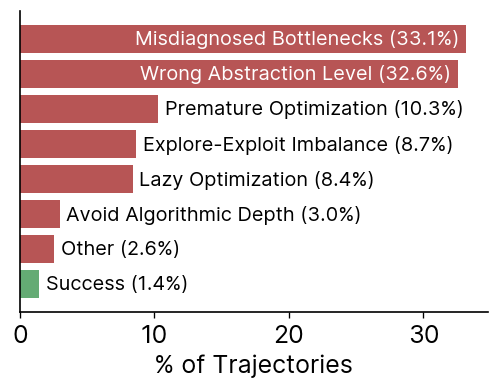

In [147]:
# load analysis from file
import pandas as pd
import matplotlib.pyplot as plt
from pyperf.harness.scripts.helpers import *

all_probs = pd.read_csv("trajectory_analysis_failed.csv")

# append successful problems
success_probs["generated_code"] = "Success"
all_probs = pd.concat([all_probs, success_probs], ignore_index=True)

# some renaming:
# Lazy/Incremental Optimization -> Lazy Optimization
all_probs["generated_code"] = all_probs["generated_code"].replace(
    {
        "Lazy/Incremental Optimization": "Lazy Optimization",
        "Lack of Algorithmic Depth": "Avoid Algorithmic Depth",
        "Missed Opportunities": "Other",
        "Over-engineering": "Other",
    }
)

# clean the generated codes
all_probs["generated_code"] = (
    all_probs["generated_code"].str.strip().str.replace("\\", "")
)

setup_plot_style()
bar_id_w_label_inside = ["Misdiagnosed Bottlenecks", "Wrong Abstraction Level"]
percentage = all_probs["generated_code"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(4.5, 3.5))
vals = percentage.sort_values()
ypos = range(len(vals))
bars = ax.barh(ypos, vals)

for bar, lbl in zip(bars, vals.index):
    width = bar.get_width()
    ycenter = bar.get_y() + bar.get_height() / 2
    bar.set_alpha(0.8)
    bar.set_height(0.8)
    if lbl == "Success":
        bar.set_color(METRICS_COLOR_MAP["Positive"])
    else:
        bar.set_color(METRICS_COLOR_MAP["Negative"])

    # remove bar border
    bar.set_edgecolor("none")

    if lbl in bar_id_w_label_inside:
        lbl = f"{lbl} ({width:.1f}%)"
        ax.text(
            width - 0.5,
            ycenter,
            lbl,
            va="center",
            ha="right",
            color="white",
            fontsize=12,
        )
    else:
        lbl = f"{lbl} ({width:.1f}%)"
        ax.text(
            width + 0.5,
            ycenter,
            lbl,
            va="center",
            ha="left",
            color="black",
            fontsize=12,
        )

ax.set_yticks([])
ax.set_xlabel("% of Trajectories")
plt.tight_layout()
plt.savefig("behaviour_dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [135]:
wrong_abstraction_level = all_probs[
    all_probs["generated_code"] == "Avoid Algorithmic Depth"
]
for i, row in wrong_abstraction_level.iterrows():
    print(f"Instance ID: {row['instance_id']}")
    print(f"Run ID: {row['run_id']}")
    print(f"Matched Human Commit Performance: {row['beat']}")
    print(f"Analysis:\n{row['analysis']}")
    print("-" * 80)

Instance ID: huggingface__tokenizers-076319d
Run ID: o4-mini_maxiter_100_N_v0.35.0-no-hint-run_3
Matched Human Commit Performance: False
Analysis:
1. Misdiagnosed Bottleneck (STEP 76–82): The agent zeroed in on the `AddedVocabulary` struct layout—duplicating regex fields and importing `ptr`—without profiling or recognizing that the real slowdown stemmed from repeated regex matching rather than data-structure layout.  
2. Overfitted to Regex Tweaks (STEP 142–161): Obsessed with superficial edits—renaming `split_re` to `split_trie`, scattering duplicate `use regex::Regex` lines—and never moved to a trie or Aho-Corasick algorithm, revealing a corrective bias toward cosmetic changes over substantive algorithmic improvements.  
3. Premature, Fragmented Refactoring (STEP 86–104): The agent repeatedly issued small, disjoint edits to `new()` and `find_matches()`, lacking a cohesive end-to-end plan. This piecemeal approach introduced code duplication and confusion instead of consolidating a cle